# Hidden CKD

#### Features
The following are the features used in this study in order of appearance
- Date of event: Date of the screening
- Gender: Gender of the patient (M: Male, F: Female)
- Ethnicity: The ethnicity of the participant
- Age: Age of the patient (years)
- Height (cm): Height of the participant in cm
- Weight (kg): Weight of the participant in kg
- BMI: BMI of the participant
- BMI Category: Classification of the particpant BMI according to NICE guidelines
- Systolic, Diastolic: The systolic and diastolic of the partcipants
- Pulse Pressure: 
- BP Category: Classification of the particpant BP according to NICE guidelines
- Has High BP:
- Has Diabetes
- Has Kidney Disease
- On BP Medication?
- On Diabetes Medication?
- On Cholesterol Medication?
- On Other Medication?
- Family History of Kidney Disease: Whether the patient has a family history of kidney disease (Definitely Yes, Definitely Not, Not Sure)
- uACR: Urine albumin to creatinine ratio of the participants as measured using a urine dipstick (Normal, Abnormal, High Abnormal)
- CKD Risk: A calculation of CKD risk by combining research findings

This is how CKD risk is calculated

low risk = sys<140, dia<90, uACR='Normal', Has_Diabetes=False or Family_KD=False<br>
moderate risk = sys<140, dia<90, uACR='Abnormal', Has_Diabetes=True or Family_KD=True<br>
high risk = sys>=180, dia>=120, uACR='High Abnormal', Has_Diabetes=False or Family_KD=False<br>

In [1]:
import numpy as np
import pandas as pd
from src.config import PROCESSED_DATA_DIR

2025-08-12 15:20:26.663 | INFO     | src.config:<module>:11 - PROJ_ROOT path is: /Users/Edward/Documents/GitHub/hidden-ckd


In [2]:
filename = PROCESSED_DATA_DIR / 'hidden_ckd_processed.csv'
df = pd.read_csv(filename)
df.head()

,Date,Gender,Ethnicity,S_Ethnicity,Ethnicity_Black,DOB,Age,Age_Category,Height,Weight,...,Has_Diabetes,Has_KD,Has_HD,BP_Meds,Diabetes_Meds,Cholesterol_Meds,Other_Meds,Family_KD,uACR,CKD_Risk
0,23/10/2022,Male,Black Caribbean,Black,True,21/05/1946,76.5,>70,161.0,64.0,...,False,False,False,False,False,False,False,Definitely not,Abnormal,Moderate
1,23/10/2022,Male,Black African (West Africa),Black,True,25/01/1970,52.8,41-55,163.0,78.0,...,False,False,False,False,False,False,False,Definitely not,Abnormal,Moderate
2,26/08/2023,Male,Black Caribbean,Black,True,14/07/2005,18.1,<25,167.0,91.0,...,False,False,False,False,False,False,False,Definitely not,Normal,Low
3,28/04/2023,Male,Black Caribbean,Black,True,25/04/1969,54.0,41-55,168.0,87.0,...,False,False,False,False,False,False,False,Definitely not,Abnormal,Moderate
4,06/11/2022,Female,Black African (West Africa),Black,True,03/11/1979,43.0,41-55,187.0,109.0,...,False,False,False,False,False,False,False,Definitely not,Abnormal,Moderate


In [3]:
def proteinuria(row):
    if (row['uACR'] == 'Abnormal' or
        row['uACR'] == 'High Abnormal'):
        return True
    else:
        return False
    
df['Has_Proteinuria'] = df.apply(proteinuria, axis=1)

## ML Models (Using Blood Pressure Readings)

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, PowerTransformer, RobustScaler, MinMaxScaler
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import EditedNearestNeighbours
from sklearn.model_selection import train_test_split
from src.utils.model_utils import stratified_split
from src.config import MODELS_DIR
import joblib

# Define features
nom_features = ['S_Ethnicity', 'Family_KD']
ord_features = ['Has_Hpt', 'Has_Diabetes']
num_features = ['Age', 'Height', 'Weight', 'Systolic', 'Diastolic']

X = df[nom_features + ord_features + num_features]
y = df['CKD_Risk'].map({'Low': 0, 'Moderate': 1, 'High': 2})

# Impute and encode values
nom_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

ord_categories = [[False, True], [False, True]]
ord_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=ord_categories))
])

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Basic preprocessor for initial data cleaning
basic_preprocessor = ColumnTransformer(
    transformers=[
        ('nom', nom_transformer, nom_features),
        ('ord', ord_transformer, ord_features),
        ('num', num_transformer, num_features),
    ])

# Apply basic preprocessing to all data
X_preprocessed = basic_preprocessor.fit_transform(X)

# Train/test split on preprocessed data
#X_train, X_test, y_train, y_test = train_test_split(
#    X_preprocessed, y, test_size=0.2, stratify=y, random_state=6)

X_train, X_test, y_train, y_test = stratified_split(pd.DataFrame(X_preprocessed), y, test_size=0.2, random_state=653)

# Resample training set
resampler = SMOTE(sampling_strategy='all', random_state=5)
X_train, y_train = resampler.fit_resample(X_train, y_train)
#resampler = ADASYN(sampling_strategy='all', random_state=23)
#X_train, y_train = resampler.fit_resample(X_train, y_train)


# Create scaler for numerical features
num_feature_indices = list(range(len(num_features)))

scaling_transformer = ColumnTransformer(
    transformers=[
        ('num_scale', PowerTransformer(method='yeo-johnson'), num_feature_indices),
        ('passthrough', 'passthrough', slice(len(num_features), None))
    ])

# Fit scaler on resampled training and test data
X_train = scaling_transformer.fit_transform(X_train)
X_test = scaling_transformer.transform(X_test)

print(f"Original training shape: {X_train.shape}")
print(f"After resampling training shape: {X_train.shape}")
print(f"Final training shape: {X_train.shape}")
print(f"Final test shape: {X_test.shape}")

preprocessor_filename = 'basic_preprocessor_bp.pkl'
joblib.dump(basic_preprocessor, MODELS_DIR / preprocessor_filename)
scaler_filename = 'scaler_bp.pkl'
joblib.dump(scaling_transformer, MODELS_DIR / scaler_filename)


Original training shape: (1452, 16)
After resampling training shape: (1452, 16)
Final training shape: (1452, 16)
Final test shape: (193, 16)


['/Users/Edward/Documents/GitHub/hidden-ckd/models/scaler_bp.pkl']

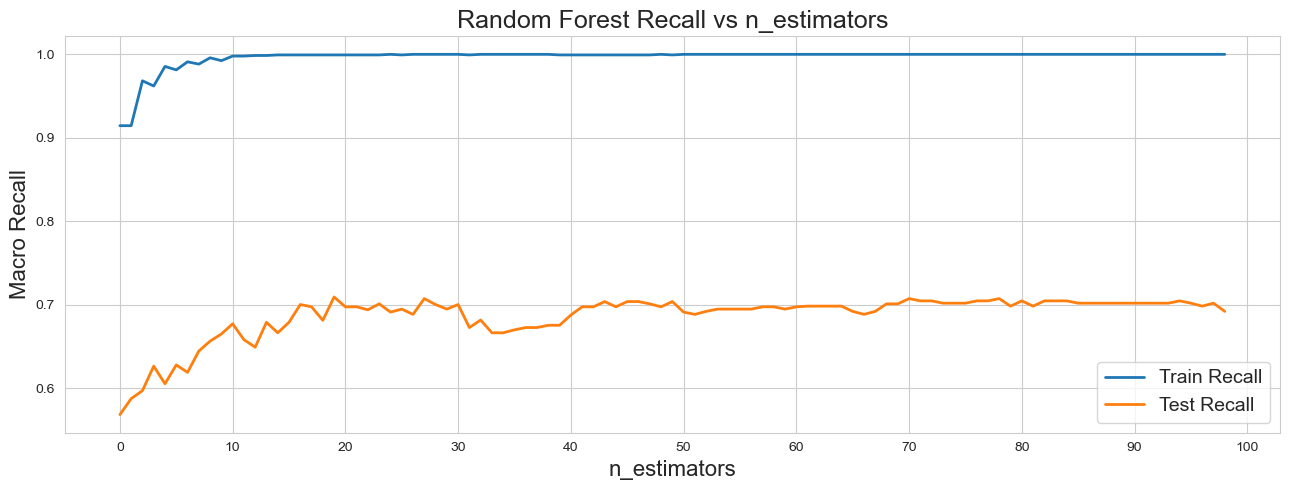

Max test recall: 0.7095 at 20 estimators


In [5]:
# Import modules
from src.utils.model_utils import resample_data, stratified_split, random_split
from src.utils.models import train_xg, train_rf, train_knn, train_lr, train_gnb, train_ensemble2, train_ensemble1, train_ensemble3

# Train Model
model_filename = 'classifier_bp.pkl'
#model = train_xg(X_train, y_train, model_filename)
model = train_rf(X_train, X_test, y_train, y_test, model_filename)
#model = train_knn(X_train, y_train, model_filename)
#model = train_lr(X_train, y_train, model_filename)
#model = train_gnb(X_train, y_train, model_filename)
#model = train_ensemble1(X_train, y_train, model_filename)

In [6]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import numpy as np

skf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

X = X_preprocessed
y = y

#for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
#    print(f"\nFold {fold + 1}")
    
#    # Split data
#    X_train, X_test = X[train_idx], X[test_idx]
#    y_train, y_test = y[train_idx], y[test_idx]
    
#    # Resample training data only
#    smote = SMOTE(random_state=42)
#    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
    
    # Train model
#    model = train_rf(X_resampled, X_test, y_resampled, y_test, model_filename)
    
    # Predict and evaluate
#    y_pred = model.predict(X_test)
#    print(classification_report(y_test, y_pred))


The data will be resampled before training (ml_bp-01) owing to the wild swings in class 2 (High Risk). This is because the number of the class 2 samples in the full dataset are too low and too noisy, meaning the nuances are not fully represented in the test set. Numerous techniques have been tested to improve the of class 2, including voting classifiers, stacked classifiers, stratified k-folds, manually setting class weights, and manipulating the random seeds, all to no marked effect.

While resampling before splitting increases the risk of data leakage and maybe overfitting, it should be noted that CKD risk classification, as used in this study, is inherently rule based, with ML only being used to 'fill in the gaps' of uACR. This is most likely the factor that is causing the highly similar real world performance between both models, despite the low recall values of the the models built by splitting before resampling the data.


Accuracy: 0.7616580310880829

Classification Report:
               precision    recall  f1-score   support

         Low       0.63      0.74      0.68        53
    Moderate       0.85      0.81      0.83       122
        High       0.64      0.50      0.56        18

    accuracy                           0.76       193
   macro avg       0.71      0.68      0.69       193
weighted avg       0.77      0.76      0.76       193



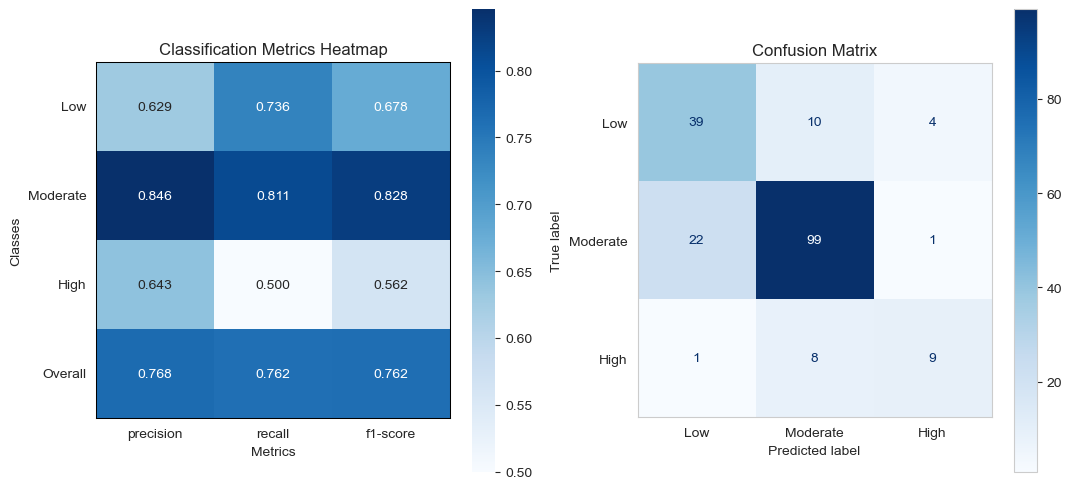

In [7]:
# Import modules
from src.utils.model_utils import load_model, evaluate_model, translate_predictions

# Load test data
target_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}

# Load model
model = load_model(model_filename)

# Evaluate model
evaluate_model(model, X_test, y_test, target_mapping)

In [8]:
data = pd.DataFrame([{
    'Age': 66,
    'Height': 154,
    'Weight': 78,
    'Systolic': 180,
    'Diastolic': 120,
    'S_Ethnicity': 'Black',
    'Family_KD': 'Definitely not',
    'Gender': 'Male',
    'Has_Hpt': True,
    'Has_Diabetes': True,
}])


# Run pipeline
full_pipeline = Pipeline(steps=[
    ('basic_preprocessor', basic_preprocessor),
    ('scaler', scaling_transformer),
    ('model', model)
])

# Prediction
prediction = full_pipeline.predict(data)
prediction = translate_predictions(prediction, target_mapping)
print("Prediction:", prediction)

probabilities = full_pipeline.predict_proba(data)
for i, probs in enumerate(probabilities):
    print(f"Sample {i}:")
    for cls, prob in enumerate(probs):
        print(f"  Class {cls} probability: {prob:.4f}")

Prediction: ['High Risk']
Sample 0:
  Class 0 probability: 0.0000
  Class 1 probability: 0.4000
  Class 2 probability: 0.6000


In [9]:
probabilities

array([[0. , 0.4, 0.6]])